<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 12px;">
    <div style="width: 100%;">
        <h2>
            <span style="color: #B30033;">▍</span>CARDIS
        </h2>
        <h1 style="margin-top: -10px;">
            Modelado, Experimentación y Validación
        </h1>
    </div>
</div>

**Notebook de Experimentación**

**Proyecto:** Clinical AI Risk Decision Support System (CARDIS)  
**Asignatura:** Desarrollo e Integración de Servicios de IA (DISIA)  
**Grupo 6:** Alonso Crespo · Diego Guerrero · José Lara · Cristina Serrano  
**Fecha:** Marzo 2026  

### Objetivo

Este notebook implementa el pipeline de experimentación del Hito 3: entrenamiento formal de cuatro modelos de clasificación con optimización bayesiana de hiperparámetros (Optuna), validación cruzada estratificada, tests estadísticos, ablation study y optimización de threshold. Los resultados alimentan los análisis de SHAP y equidad/calibración.

### Research Questions abordadas

- **RQ1:** ¿Qué modelo ofrece el mejor equilibrio rendimiento-explicabilidad para CARDIS?
- **RQ2:** ¿Cuánto aporta la ingeniería de características clínicas al rendimiento? (ablation study)

## 0. Configuración del entorno

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import json

# ML — modelos y evaluación
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_auc_score,
    brier_score_loss, make_scorer, classification_report
)
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Modelos de boosting
import lightgbm as lgb
import xgboost as xgb

# Optimización bayesiana de hiperparámetros
import optuna
from optuna.samplers import TPESampler

# Tests estadísticos para comparación de clasificadores
from scipy.stats import wilcoxon

# Serialización del modelo final
import joblib

# ── Configuración global ──────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

# Semilla para reproducibilidad total del experimento
SEED = 42
np.random.seed(SEED)

# Directorios de salida (relativos al directorio del notebook, hito3/)
os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Entorno configurado correctamente.")
print(f"  NumPy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scikit-learn: {__import__('sklearn').__version__}")
print(f"  LightGBM   : {lgb.__version__}")
print(f"  XGBoost    : {xgb.__version__}")
print(f"  Optuna     : {optuna.__version__}")
print(f"  SEED       : {SEED}")


Entorno configurado correctamente.
  NumPy       : 2.2.6
  pandas      : 2.3.3
  scikit-learn: 1.7.2
  LightGBM   : 4.6.0
  XGBoost    : 3.0.5
  Optuna     : 4.4.0
  SEED       : 42


c:\venvs\disia_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos y preparación

Los datos provienen del pipeline de preprocesamiento del Hito 2 (`cardis_pipeline.ipynb`), que exportó dos versiones del dataset de entrenamiento:

| Archivo | Contenido | Uso |
|---------|-----------|-----|
| `cardio_risk_train_fe.csv` | Solo Feature Engineering (sin escalar) | Modelos de árboles (RF, LightGBM, XGBoost) |
| `cardio_risk_train_pipeline.csv` | FE + imputación + Target Encoding + RobustScaler | Regresión Logística |

La razón de tener dos versiones es que los modelos basados en árboles son invariantes al escalado de las variables, mientras que la Regresión Logística requiere que las features estén en escalas comparables para que los coeficientes sean estables y la convergencia sea eficiente.


### 1.1 Target Encoder

Reutilizamos la misma implementación del `TargetEncoder` definida en `cardis_pipeline.ipynb`. Se ajusta **siempre sobre el conjunto de entrenamiento** de cada fold para evitar *data leakage*: si se ajustara sobre todo el dataset, las medias del target filtrarían información del conjunto de validación al de entrenamiento.


In [2]:
# ── Target Encoder (replicado de cardis_pipeline.ipynb) ────────────────────────
# Sustituye cada categoría por la media suavizada del target en esa categoría.
# El smoothing evita sobreajuste en categorías con pocas observaciones.
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns, smoothing=1.0):
        self.columns = columns
        self.smoothing = smoothing
        self.mapping_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        X = X.copy()
        self.global_mean_ = y.mean()
        for col in self.columns:
            if col in X.columns:
                stats = y.groupby(X[col]).agg(['mean', 'count'])
                # Fórmula de suavizado: pondera entre la media de la categoría
                # y la media global según el nº de observaciones
                smooth = (
                    (stats['count'] * stats['mean'] + self.smoothing * self.global_mean_)
                    / (stats['count'] + self.smoothing)
                )
                self.mapping_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            if col in X.columns:
                # Categorías no vistas en fit se rellenan con la media global
                X[col] = X[col].map(self.mapping_.get(col, {})).fillna(self.global_mean_)
        return X


### 1.2 Carga y partición de datos

In [3]:
# ── Carga de datos procesados ──────────────────────────────────────────────────
# Ruta relativa desde hito3/ hasta data/processed/
DATA_DIR = '../data/processed'

df_fe = pd.read_csv(f'{DATA_DIR}/cardio_risk_train_fe.csv')
df_pipe = pd.read_csv(f'{DATA_DIR}/cardio_risk_train_pipeline.csv')
df_test_fe = pd.read_csv(f'{DATA_DIR}/cardio_risk_test_fe.csv')

print(f"Train (FE)       : {df_fe.shape}")
print(f"Train (Pipeline) : {df_pipe.shape}")
print(f"Test  (FE)       : {df_test_fe.shape}")

# ── Separar features (X) y target (y) ─────────────────────────────────────────
TARGET = 'riesgo_cv'
y = df_fe[TARGET]
X_fe = df_fe.drop(columns=[TARGET])

# Versión pipeline para LogReg (ya tiene TE + imputer + scaler aplicados)
X_pipe = df_pipe.drop(columns=[TARGET])
y_pipe = df_pipe[TARGET]

# Variables de alta cardinalidad que necesitan Target Encoding
alta_cardinalidad = ['hospital_origen', 'codigo_postal']
cols_alta_card_fe = [c for c in alta_cardinalidad if c in X_fe.columns]

print(f"\nDistribución target: {y.value_counts().to_dict()}")
print(f"Prevalencia alto riesgo: {y.mean():.3f}")
print(f"Variables en X_fe: {X_fe.shape[1]}")
print(f"Variables de alta cardinalidad: {cols_alta_card_fe}")


Train (FE)       : (24000, 39)
Train (Pipeline) : (24000, 39)
Test  (FE)       : (16000, 38)

Distribución target: {0: 18744, 1: 5256}
Prevalencia alto riesgo: 0.219
Variables en X_fe: 38
Variables de alta cardinalidad: ['hospital_origen', 'codigo_postal']


In [4]:
# ── Partición train/validation ─────────────────────────────────────────────────
# Misma partición 80/20 estratificada que en el Hito 2 (seed=42)
X_train_fe, X_val_fe, y_train, y_val = train_test_split(
    X_fe, y, test_size=0.2, random_state=SEED, stratify=y
)

# Partición equivalente sobre los datos ya procesados por el pipeline (para LogReg)
X_train_pipe, X_val_pipe, _, _ = train_test_split(
    X_pipe, y_pipe, test_size=0.2, random_state=SEED, stratify=y_pipe
)

# ── Validación cruzada estratificada ──────────────────────────────────────────
# Mismo esquema que en el Hito 2: 5 folds, shuffle, seed=42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Partición 80/20 estratificada:")
print(f"  Train : {X_train_fe.shape[0]:,} registros | Alto riesgo: {y_train.mean():.3f}")
print(f"  Val   : {X_val_fe.shape[0]:,}  registros | Alto riesgo: {y_val.mean():.3f}")
print(f"\nValidación cruzada: StratifiedKFold(5, shuffle=True, seed={SEED})")


Partición 80/20 estratificada:
  Train : 19,200 registros | Alto riesgo: 0.219
  Val   : 4,800  registros | Alto riesgo: 0.219

Validación cruzada: StratifiedKFold(5, shuffle=True, seed=42)


## 2. Definición de métricas

Se evalúa cada modelo con seis métricas complementarias. La elección de **F1-Score como métrica principal** responde al desbalanceo del dataset (78% bajo riesgo / 22% alto riesgo): la *accuracy* sería engañosa, ya que un clasificador trivial que siempre predijera "bajo riesgo" obtendría un 78% de exactitud con un recall del 0%.

| Métrica | Qué mide | Por qué importa en CARDIS |
|---------|----------|---------------------------|
| **F1-Score** | Media armónica de precision y recall | Equilibra la detección de pacientes de riesgo con la minimización de alarmas falsas |
| **Recall** | Proporción de positivos reales detectados | Un FN es un paciente de alto riesgo no identificado — el error más grave clínicamente |
| **Precision** | Proporción de predicciones positivas correctas | Un FP genera ansiedad innecesaria y pruebas redundantes |
| **AUC-ROC** | Capacidad discriminativa global | Evalúa el modelo en todos los thresholds posibles, no solo en 0.5 |
| **Brier Score** | Calibración de las probabilidades | Si las probabilidades son fiables, CARDIS puede mostrarlas al médico |
| **Tiempo** | Duración del entrenamiento | Relevante para el despliegue en tiempo real |


In [ ]:
# ── Función de evaluación unificada ────────────────────────────────────────────
def evaluar_modelo_cv(model, X, y, cv, nombre, es_pipeline=False, threshold=0.5):
    """
    Evalúa un modelo con 5-fold CV estratificado y devuelve un diccionario con:
    - Media ± std de cada métrica
    - Scores individuales por fold (para tests estadísticos)
    - Predicciones por fold (y_true, y_pred, y_proba) para análisis posteriores
    
    Parámetros:
    - es_pipeline: si True, los datos ya tienen TE+imputer+scaler aplicados
                   (caso de LogReg). Si False, se aplican dentro de cada fold.
    """
    metricas_fold = {
        'f1': [], 'recall': [], 'precision': [],
        'auc_roc': [], 'brier': [], 'tiempo': []
    }
    predicciones_fold = []  # Para equidad/calibración
    
    print(f"\n  Evaluando {nombre}...")
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]
        
        t_fold = time.time()
        
        if not es_pipeline:
            # Aplicar TE + imputación DENTRO del fold para evitar data leakage
            te = TargetEncoder(columns=cols_alta_card_fe, smoothing=1.0)
            te.fit(X_tr, y_tr)
            X_tr = te.transform(X_tr)
            X_vl = te.transform(X_vl)
            
            imp = SimpleImputer(strategy='median')
            X_tr = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
            X_vl = pd.DataFrame(imp.transform(X_vl), columns=X_vl.columns, index=X_vl.index)
        
        # Entrenar y predecir
        model.fit(X_tr, y_tr)
        t_fit = time.time() - t_fold
        
        y_proba = model.predict_proba(X_vl)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        # Registrar métricas de este fold
        metricas_fold['f1'].append(f1_score(y_vl, y_pred))
        metricas_fold['recall'].append(recall_score(y_vl, y_pred))
        metricas_fold['precision'].append(precision_score(y_vl, y_pred))
        metricas_fold['auc_roc'].append(roc_auc_score(y_vl, y_proba))
        metricas_fold['brier'].append(brier_score_loss(y_vl, y_proba))
        metricas_fold['tiempo'].append(t_fit)
        
        # Guardar predicciones individuales
        predicciones_fold.append(pd.DataFrame({
            'fold': fold_idx, 'idx': y_vl.index,
            'y_true': y_vl.values, 'y_pred': y_pred, 'y_proba': y_proba
        }))
        
        print(f"    Fold {fold_idx+1}/5 — F1={metricas_fold['f1'][-1]:.4f} "
              f"({t_fit:.1f}s)")
    
    # Construir resumen con media ± std
    resumen = {}
    for k, v in metricas_fold.items():
        resumen[f'{k}_mean'] = np.mean(v)
        resumen[f'{k}_std'] = np.std(v)
    resumen['nombre'] = nombre
    resumen['scores_fold'] = metricas_fold
    resumen['predicciones'] = pd.concat(predicciones_fold, ignore_index=True)
    
    return resumen


def imprimir_resumen(res):
    """Imprime las métricas de un modelo de forma compacta."""
    print(f"\n{'='*60}")
    print(f"  {res['nombre']}")
    print(f"{'='*60}")
    print(f"  F1-Score  : {res['f1_mean']:.4f} ± {res['f1_std']:.4f}")
    print(f"  Recall    : {res['recall_mean']:.4f} ± {res['recall_std']:.4f}")
    print(f"  Precision : {res['precision_mean']:.4f} ± {res['precision_std']:.4f}")
    print(f"  AUC-ROC   : {res['auc_roc_mean']:.4f} ± {res['auc_roc_std']:.4f}")
    print(f"  Brier     : {res['brier_mean']:.4f} ± {res['brier_std']:.4f}")
    print(f"  Tiempo    : {res['tiempo_mean']:.2f}s ± {res['tiempo_std']:.2f}s")

print("Funciones de evaluación definidas.")


Funciones de evaluación definidas.


## 3. Optimización de hiperparámetros con Optuna

En lugar de una búsqueda exhaustiva (*grid search*) o aleatoria (*random search*), empleamos **Optuna** con el *sampler* bayesiano **TPE** (*Tree-structured Parzen Estimator*). TPE modela la distribución de los hiperparámetros que producen buenos resultados y la de los que producen malos, y propone nuevas combinaciones que maximizan la probabilidad de caer en la primera. Esto hace que la búsqueda sea más eficiente que *grid search*, especialmente en espacios amplios con muchos hiperparámetros.

**Protocolo:** para cada modelo, Optuna ejecuta **100 trials**. En cada trial:
1. TPE propone una combinación de hiperparámetros.
2. Se entrena el modelo con esa combinación usando **5-fold CV estratificado**.
3. Se calcula el **F1-Score medio** sobre los 5 folds.
4. Optuna registra el resultado y actualiza su modelo interno para el siguiente trial.

Al terminar, nos quedamos con la combinación de hiperparámetros que produjo el mejor F1 medio.

> **Nota sobre data leakage:** dentro de cada fold del CV, el Target Encoding y la imputación se ajustan solo sobre el subconjunto de entrenamiento de ese fold, nunca sobre la validación. Esto garantiza que no filtramos información del target al entrenar.


### 3.0 Definición de la función de optimización y espacios de búsqueda

In [6]:
# ── Número de trials por modelo ────────────────────────────────────────────────
N_TRIALS = 100

def optimizar_con_optuna(nombre, crear_modelo_fn, X, y, cv, n_trials=N_TRIALS):
    """
    Optimiza hiperparámetros de un modelo basado en árboles con Optuna.
    
    Para cada trial, entrena con 5-fold CV aplicando TE+imputer dentro
    de cada fold. Retorna los mejores parámetros, el mejor score y el study.
    """
    def objective(trial):
        model = crear_modelo_fn(trial)
        scores = []
        
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]
            
            # TE + imputer ajustados solo sobre train del fold
            te = TargetEncoder(columns=cols_alta_card_fe, smoothing=1.0)
            te.fit(X_tr, y_tr)
            X_tr_t = te.transform(X_tr)
            X_vl_t = te.transform(X_vl)
            
            imp = SimpleImputer(strategy='median')
            X_tr_t = pd.DataFrame(imp.fit_transform(X_tr_t), columns=X_tr_t.columns)
            X_vl_t = pd.DataFrame(imp.transform(X_vl_t), columns=X_vl_t.columns)
            
            model.fit(X_tr_t, y_tr)
            y_pred = model.predict(X_vl_t)
            scores.append(f1_score(y_vl, y_pred))
        
        return np.mean(scores)
    
    sampler = TPESampler(seed=SEED)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    
    print(f"\nOptimizando {nombre} ({n_trials} trials)...")
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    elapsed = time.time() - t0
    
    print(f"  ✓ Mejor F1 (CV): {study.best_value:.4f}")
    print(f"  ✓ Tiempo total: {elapsed:.0f}s ({elapsed/n_trials:.1f}s/trial)")
    print(f"  ✓ Mejores parámetros: {study.best_params}")
    
    return study.best_params, study.best_value, study

print("Función de optimización genérica definida.")


Función de optimización genérica definida.


In [7]:
# ── Espacios de hiperparámetros para cada modelo ──────────────────────────────
# Cada función recibe un trial de Optuna y devuelve un modelo instanciado.

def crear_logreg(trial):
    """Regresión Logística con solver liblinear (rápido, soporta L1 y L2)."""
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    cw_str = trial.suggest_categorical('class_weight', ['None', 'balanced'])
    cw = None if cw_str == 'None' else 'balanced'
    # liblinear es mucho más rápido que saga para datasets de este tamaño
    # y soporta tanto L1 como L2 sin problemas de convergencia
    return LogisticRegression(
        C=C, penalty=penalty, solver='liblinear', class_weight=cw,
        max_iter=300, random_state=SEED
    )

def crear_rf(trial):
    """Random Forest: robusto frente a outliers, captura no linealidades."""
    cw_str = trial.suggest_categorical('class_weight', ['None', 'balanced', 'balanced_subsample'])
    cw = None if cw_str == 'None' else cw_str
    return RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500, step=100),
        max_depth=trial.suggest_int('max_depth', 5, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        class_weight=cw,
        n_jobs=-1, random_state=SEED
    )

def crear_lgbm(trial):
    """LightGBM: candidato principal según experiencia previa con este dataset."""
    # scale_pos_weight: 1.0 (sin ajuste) o ~3.56 (ratio de desbalanceo 78/22)
    scale_pw = trial.suggest_categorical('scale_pos_weight', [1.0, 3.56])
    return lgb.LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 12),
        num_leaves=trial.suggest_int('num_leaves', 15, 127),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 50),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 1.0),   # Regularización L1
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 1.0),  # Regularización L2
        subsample=trial.suggest_float('subsample', 0.6, 1.0),    # Fracción de filas por árbol
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),  # Fracción de features
        scale_pos_weight=scale_pw,
        random_state=SEED, verbose=-1, n_jobs=-1
    )

def crear_xgb(trial):
    """XGBoost: segundo modelo de boosting para verificar robustez de resultados."""
    scale_pw = trial.suggest_categorical('scale_pos_weight_xgb', [1.0, 3.56])
    return xgb.XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 12),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 1.0),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        scale_pos_weight=scale_pw,
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, verbosity=0
    )

print("Espacios de hiperparámetros definidos:")
print("  1. Regresión Logística — C ∈ [0.01, 10], penalty ∈ {L1, L2}")
print("  2. Random Forest       — n_estimators ∈ [100, 500], max_depth ∈ [5, 20]")
print("  3. LightGBM            — 9 hiperparámetros, rangos amplios")
print("  4. XGBoost             — espacio análogo a LightGBM")


Espacios de hiperparámetros definidos:
  1. Regresión Logística — C ∈ [0.01, 10], penalty ∈ {L1, L2}
  2. Random Forest       — n_estimators ∈ [100, 500], max_depth ∈ [5, 20]
  3. LightGBM            — 9 hiperparámetros, rangos amplios
  4. XGBoost             — espacio análogo a LightGBM


### 3.1 Optimización: Regresión Logística (baseline)

La Regresión Logística se entrena sobre los **datos del pipeline completo** (ya escalados con `RobustScaler`), ya que es un modelo sensible a la escala de las variables. A diferencia de los modelos de árboles, no necesitamos aplicar Target Encoding ni imputación dentro del loop de Optuna porque ya vienen aplicados en el CSV del pipeline.

Se utiliza el *solver* `liblinear`, que es considerablemente más rápido que `saga` para datasets de este tamaño y soporta tanto L1 como L2. El espacio de búsqueda de `C` se ha acotado a `[0.01, 10]` (en escala logarítmica) para evitar combinaciones con poca regularización que no aportan mejora.


In [8]:
# ── Optimización de LogReg (datos ya procesados por el pipeline) ──────────────
def optimizar_logreg(n_trials=N_TRIALS):
    def objective(trial):
        model = crear_logreg(trial)
        scores = []
        for train_idx, val_idx in cv.split(X_pipe, y_pipe):
            X_tr = X_pipe.iloc[train_idx]
            X_vl = X_pipe.iloc[val_idx]
            y_tr = y_pipe.iloc[train_idx]
            y_vl = y_pipe.iloc[val_idx]
            
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_vl)
            scores.append(f1_score(y_vl, y_pred))
        
        return np.mean(scores)
    
    sampler = TPESampler(seed=SEED)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    
    print(f"Optimizando Regresión Logística ({n_trials} trials)...")
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials)
    elapsed = time.time() - t0
    
    print(f"  ✓ Mejor F1 (CV): {study.best_value:.4f}")
    print(f"  ✓ Tiempo total: {elapsed:.0f}s ({elapsed/n_trials:.1f}s/trial)")
    print(f"  ✓ Params: {study.best_params}")
    return study.best_params, study.best_value, study

params_lr, score_lr, study_lr = optimizar_logreg()


Optimizando Regresión Logística (100 trials)...
  ✓ Mejor F1 (CV): 0.7158
  ✓ Tiempo total: 306s (3.1s/trial)
  ✓ Params: {'C': 5.703220941540322, 'penalty': 'l2', 'class_weight': 'balanced'}


### 3.2 Optimización: Random Forest, LightGBM y XGBoost

Los tres modelos de árboles operan sobre los **datos con Feature Engineering pero sin escalar** (`cardio_risk_train_fe.csv`). Dentro de cada trial y cada fold, se aplica el Target Encoding y la imputación por mediana para evitar *data leakage*.

> **⏱ Nota de tiempos:** cada trial ejecuta 5 entrenamientos (uno por fold). Con 100 trials por modelo y 3 modelos, esto supone ~1500 entrenamientos. LightGBM y XGBoost suelen ser los más rápidos; Random Forest puede tardar más por el mayor número de árboles evaluados.


In [9]:
# ── Optimización secuencial de los tres modelos de árboles ────────────────────
params_rf, score_rf, study_rf = optimizar_con_optuna(
    'Random Forest', crear_rf, X_fe, y, cv
)

params_lgbm, score_lgbm, study_lgbm = optimizar_con_optuna(
    'LightGBM', crear_lgbm, X_fe, y, cv
)

params_xgb, score_xgb, study_xgb = optimizar_con_optuna(
    'XGBoost', crear_xgb, X_fe, y, cv
)

# ── Resumen comparativo de la optimización ────────────────────────────────────
print("\n" + "="*60)
print("RESUMEN DE OPTIMIZACIÓN (mejor F1 medio por modelo)")
print("="*60)
for nombre, score in [('LogReg', score_lr), ('RF', score_rf),
                       ('LightGBM', score_lgbm), ('XGBoost', score_xgb)]:
    print(f"  {nombre:<12}: F1 = {score:.4f}")



Optimizando Random Forest (100 trials)...
  ✓ Mejor F1 (CV): 0.6798
  ✓ Tiempo total: 2661s (26.6s/trial)
  ✓ Mejores parámetros: {'class_weight': 'balanced_subsample', 'n_estimators': 400, 'max_depth': 19, 'min_samples_leaf': 9}

Optimizando LightGBM (100 trials)...
  ✓ Mejor F1 (CV): 0.7197
  ✓ Tiempo total: 861s (8.6s/trial)
  ✓ Mejores parámetros: {'scale_pos_weight': 3.56, 'n_estimators': 450, 'learning_rate': 0.08951607509392116, 'max_depth': 5, 'num_leaves': 107, 'min_child_samples': 15, 'reg_alpha': 0.2872625748228286, 'reg_lambda': 0.987140522099518, 'subsample': 0.8340187281561661, 'colsample_bytree': 0.7558495941631742}

Optimizando XGBoost (100 trials)...
  ✓ Mejor F1 (CV): 0.7178
  ✓ Tiempo total: 700s (7.0s/trial)
  ✓ Mejores parámetros: {'scale_pos_weight_xgb': 3.56, 'n_estimators': 350, 'learning_rate': 0.06484606395788177, 'max_depth': 6, 'min_child_weight': 1, 'reg_alpha': 0.29695757599130046, 'reg_lambda': 0.3699788714938064, 'subsample': 0.9851907753825341, 'colsam

Varios patrones relevantes emergen de la búsqueda de hiperparámetros:

**Convergencia de los modelos de *boosting*:** LightGBM (F1 = 0,7197) y XGBoost (F1 = 0,7178) obtienen resultados prácticamente idénticos, separados por menos de 0,002 puntos. Esto es esperable: ambos implementan variantes del *gradient boosting* sobre árboles y, dado un pipeline de datos sólido, tienden a converger en rendimiento. La diferencia operativa está en la velocidad: LightGBM termina en 861s frente a 700s de XGBoost, aunque ambos son rápidos comparados con Random Forest (2661s).

**Regresión Logística competitiva:** Con F1 = 0,7158, el *baseline* lineal queda sorprendentemente cerca de los modelos de *boosting* (apenas 0,004 puntos por debajo de LightGBM). Esto sugiere que una parte sustancial de la señal predictiva del dataset es capturada por relaciones lineales, lo cual es coherente con la evidencia epidemiológica: la edad, el LDL y la presión sistólica tienen relaciones monótonas bien establecidas con el riesgo cardiovascular.

**Random Forest por debajo:** Con F1 = 0,6798, Random Forest queda claramente rezagado. Los *bagging ensembles* suelen ser menos eficientes que los métodos de *boosting* cuando las relaciones entre variables son aditivas, como ocurre aquí.

**Hiperparámetros óptimos - patrones comunes:** Los tres modelos de árboles seleccionaron `scale_pos_weight = 3,56` (ratio de desbalanceo ~78/22), lo que confirma que manejar el desbalanceo de clases a nivel del modelo es preferible a técnicas de *oversampling* (el *oversampling* es una técnica que consiste en aumentar la cantidad de ejemplos de la clase minoritaria). LightGBM converge a una configuración relativamente regularizada (`reg_lambda ≈ 0,99`, `subsample ≈ 0,83`, `colsample ≈ 0,76`), lo que indica que la regularización protege frente al sobreajuste en un dataset de solo 24.000 registros.

## 4. Evaluación formal con hiperparámetros óptimos

La optimización con Optuna nos ha dado los mejores hiperparámetros para cada modelo. Ahora los fijamos y evaluamos los cuatro modelos con el **protocolo completo de métricas** (F1, Recall, Precision, AUC-ROC, Brier, tiempo) sobre los mismos 5 folds. Esto nos da las cifras definitivas que irán a la tabla comparativa de la memoria.


### 4.0 Instanciación de modelos con parámetros óptimos

In [10]:
# ── Instanciar cada modelo con los hiperparámetros encontrados por Optuna ─────

# Regresión Logística (usa datos pipeline escalados)
cw_lr = None if params_lr.get('class_weight', 'None') == 'None' else 'balanced'
modelo_lr = LogisticRegression(
    C=params_lr['C'], penalty=params_lr['penalty'],
    solver='liblinear', class_weight=cw_lr,
    max_iter=300, random_state=SEED
)

# Random Forest
cw_rf = None if params_rf.get('class_weight', 'None') == 'None' else params_rf['class_weight']
modelo_rf = RandomForestClassifier(
    n_estimators=params_rf['n_estimators'],
    max_depth=params_rf['max_depth'],
    min_samples_leaf=params_rf['min_samples_leaf'],
    class_weight=cw_rf,
    n_jobs=-1, random_state=SEED
)

# LightGBM
spw_lgbm = params_lgbm.get('scale_pos_weight', 1.0)
modelo_lgbm = lgb.LGBMClassifier(
    n_estimators=params_lgbm['n_estimators'],
    learning_rate=params_lgbm['learning_rate'],
    max_depth=params_lgbm['max_depth'],
    num_leaves=params_lgbm['num_leaves'],
    min_child_samples=params_lgbm['min_child_samples'],
    reg_alpha=params_lgbm['reg_alpha'],
    reg_lambda=params_lgbm['reg_lambda'],
    subsample=params_lgbm['subsample'],
    colsample_bytree=params_lgbm['colsample_bytree'],
    scale_pos_weight=spw_lgbm,
    random_state=SEED, verbose=-1, n_jobs=-1
)

# XGBoost
spw_xgb = params_xgb.get('scale_pos_weight_xgb', 1.0)
modelo_xgb = xgb.XGBClassifier(
    n_estimators=params_xgb['n_estimators'],
    learning_rate=params_xgb['learning_rate'],
    max_depth=params_xgb['max_depth'],
    min_child_weight=params_xgb.get('min_child_weight', 1),
    reg_alpha=params_xgb['reg_alpha'],
    reg_lambda=params_xgb['reg_lambda'],
    subsample=params_xgb['subsample'],
    colsample_bytree=params_xgb['colsample_bytree'],
    scale_pos_weight=spw_xgb,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)

print("Modelos instanciados con hiperparámetros óptimos de Optuna.")


Modelos instanciados con hiperparámetros óptimos de Optuna.


### 4.0.1 Evaluación 5-fold CV

In [11]:
# ── Evaluación formal de cada modelo ───────────────────────────────────────────

# LogReg: datos pipeline (ya escalados) → es_pipeline=True
res_lr = evaluar_modelo_cv(modelo_lr, X_pipe, y_pipe, cv,
                            'Regresión Logística', es_pipeline=True)

# Modelos de árboles: datos FE (sin escalar) → TE+imputer se aplican por fold
res_rf = evaluar_modelo_cv(modelo_rf, X_fe, y, cv, 'Random Forest')
res_lgbm = evaluar_modelo_cv(modelo_lgbm, X_fe, y, cv, 'LightGBM')
res_xgb = evaluar_modelo_cv(modelo_xgb, X_fe, y, cv, 'XGBoost')

resultados = [res_lr, res_rf, res_lgbm, res_xgb]

# Imprimir resúmenes
for r in resultados:
    imprimir_resumen(r)



  Evaluando Regresión Logística...
    Fold 1/5 — F1=0.7083 (0.6s)
    Fold 2/5 — F1=0.7144 (0.4s)
    Fold 3/5 — F1=0.7103 (0.6s)
    Fold 4/5 — F1=0.7231 (0.6s)
    Fold 5/5 — F1=0.7230 (0.6s)

  Evaluando Random Forest...
    Fold 1/5 — F1=0.6781 (7.2s)
    Fold 2/5 — F1=0.6749 (5.8s)
    Fold 3/5 — F1=0.6797 (5.5s)
    Fold 4/5 — F1=0.6835 (5.3s)
    Fold 5/5 — F1=0.6830 (5.3s)

  Evaluando LightGBM...
    Fold 1/5 — F1=0.7039 (0.9s)
    Fold 2/5 — F1=0.7166 (1.0s)
    Fold 3/5 — F1=0.7106 (0.9s)
    Fold 4/5 — F1=0.7228 (1.2s)
    Fold 5/5 — F1=0.7445 (1.3s)

  Evaluando XGBoost...
    Fold 1/5 — F1=0.7044 (1.6s)
    Fold 2/5 — F1=0.7141 (1.3s)
    Fold 3/5 — F1=0.7114 (1.3s)
    Fold 4/5 — F1=0.7234 (1.4s)
    Fold 5/5 — F1=0.7355 (1.4s)

  Regresión Logística
  F1-Score  : 0.7158 ± 0.0062
  Recall    : 0.8617 ± 0.0139
  Precision : 0.6123 ± 0.0081
  AUC-ROC   : 0.9313 ± 0.0033
  Brier     : 0.1067 ± 0.0018
  Tiempo    : 0.57s ± 0.07s

  Random Forest
  F1-Score  : 0.6798 ± 0.00

### 4.1 Tabla comparativa global (→ Sección 3.4.1 de la memoria)

In [12]:
# ── Construir y exportar tabla comparativa ─────────────────────────────────────
filas = []
for r in resultados:
    filas.append({
        'Modelo': r['nombre'],
        'F1': f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
        'Recall': f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
        'Precision': f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
        'AUC-ROC': f"{r['auc_roc_mean']:.4f} ± {r['auc_roc_std']:.4f}",
        'Brier': f"{r['brier_mean']:.4f} ± {r['brier_std']:.4f}",
        'Tiempo (s)': f"{r['tiempo_mean']:.2f}",
    })

df_comparativa = pd.DataFrame(filas)
print("\nTABLA COMPARATIVA — 5-Fold CV Estratificado (threshold=0.5)")
print("="*100)
print(df_comparativa.to_string(index=False))

# Exportar para la memoria y reutilización
df_comparativa.to_csv('outputs/tabla_comparativa_modelos.csv', index=False)

# Identificar mejor modelo
mejor = max(resultados, key=lambda r: r['f1_mean'])
print(f"\n→ Mejor modelo por F1: {mejor['nombre']} (F1 = {mejor['f1_mean']:.4f})")
print(f"→ Tabla exportada: outputs/tabla_comparativa_modelos.csv")



TABLA COMPARATIVA — 5-Fold CV Estratificado (threshold=0.5)
             Modelo              F1          Recall       Precision         AUC-ROC           Brier Tiempo (s)
Regresión Logística 0.7158 ± 0.0062 0.8617 ± 0.0139 0.6123 ± 0.0081 0.9313 ± 0.0033 0.1067 ± 0.0018       0.57
      Random Forest 0.6798 ± 0.0032 0.7359 ± 0.0081 0.6317 ± 0.0033 0.9077 ± 0.0031 0.1075 ± 0.0009       5.80
           LightGBM 0.7197 ± 0.0139 0.7801 ± 0.0219 0.6681 ± 0.0117 0.9246 ± 0.0059 0.0959 ± 0.0036       1.07
            XGBoost 0.7178 ± 0.0107 0.7757 ± 0.0137 0.6679 ± 0.0094 0.9243 ± 0.0055 0.0951 ± 0.0032       1.39

→ Mejor modelo por F1: LightGBM (F1 = 0.7197)
→ Tabla exportada: outputs/tabla_comparativa_modelos.csv


Los resultados revelan un panorama más matizado de lo esperado inicialmente:

**F1-Score:** LightGBM lidera (0,7197), pero la diferencia respecto a Regresión Logística (0,7158) y XGBoost (0,7178) es inferior a un punto porcentual. Random Forest queda claramente por detrás (0,6798). La desviación estándar de LightGBM (±0,0139) es la más alta, lo que indica algo más de variabilidad entre folds, un aspecto a tener en cuenta para la robustez.

**El *trade-off* precision–recall:** Aquí es donde las diferencias son más informativas que en el F1 agregado. La Regresión Logística tiene el recall más alto del estudio (0,8617): detecta el 86% de los pacientes de alto riesgo, pero a costa de una precisión de solo 0,6123; es decir, casi 4 de cada 10 predicciones de alto riesgo son falsos positivos (pacientes predichos como de alto riesgo pero que no lo son). LightGBM y XGBoost ofrecen un perfil más equilibrado: su recall es menor (∼0,78), pero su precisión sube a ∼0,668, reduciendo los falsos positivos. En un contexto clínico, el punto óptimo dependerá de si el sistema prioriza no perder ningún paciente de riesgo (más recall) o no sobrecargar con alarmas falsas (más precisión). CARDIS, como sistema *human-in-the-loop*, se beneficia de un equilibrio razonable.

**AUC-ROC — una sorpresa:** La Regresión Logística obtiene el AUC-ROC más alto (0,9313), por encima de LightGBM (0,9246). Esto puede parecer contradictorio, pero tiene explicación: el AUC mide la capacidad discriminativa *a lo largo de todos los thresholds posibles*, no solo en 0,5. LogReg, al usar `class_weight='balanced'`, produce probabilidades más dispersas que facilitan la separación de clases. Sin embargo, este AUC alto no se traduce directamente en mejor F1 porque el F1 depende del threshold operativo concreto.

**Calibración (Brier Score):** XGBoost (0,0951) y LightGBM (0,0959) presentan las mejores calibraciones, lo que significa que las probabilidades que emiten son más fiables como estimación real del riesgo. Esto es relevante para CARDIS: si mostramos la probabilidad al médico en la interfaz, interesa que un "70% de riesgo" signifique realmente un 70% y no un 50%.

**Tiempo:** La Regresión Logística es 10× más rápida que LightGBM (0,57s vs 1,07s), y 5× más rápida que Random Forest. 

### 4.2 Tests estadísticos de Wilcoxon (→ Sección 3.4.2 de la memoria)

El test de **Wilcoxon *signed-rank*** compara dos distribuciones pareadas de scores. Para cada par de modelos, tomamos sus 5 valores de F1 (uno por fold, calculados sobre los mismos datos) y comprobamos si la diferencia es estadísticamente significativa.

Con solo 5 observaciones, el poder estadístico es limitado: la diferencia mínima detectable es grande. Esto es una limitación conocida y aceptada en la literatura (Demšar, 2006). Una diferencia no significativa no implica que los modelos sean equivalentes — puede simplemente reflejar falta de potencia.


In [13]:
# ── Tests de Wilcoxon entre todos los pares de modelos ────────────────────────
nombres = [r['nombre'] for r in resultados]
scores_f1 = {r['nombre']: r['scores_fold']['f1'] for r in resultados}

print("TESTS DE WILCOXON SIGNED-RANK (sobre F1 por fold)")
print("="*75)
print(f"{'Par':<42} {'Δ F1':>8} {'p-valor':>10} {'Sig. (α=0.05)':>15}")
print("-"*75)

pares_tests = []
for i in range(len(resultados)):
    for j in range(i+1, len(resultados)):
        n1, n2 = nombres[i], nombres[j]
        s1, s2 = np.array(scores_f1[n1]), np.array(scores_f1[n2])
        delta = np.mean(s2) - np.mean(s1)
        
        # Wilcoxon requiere que haya diferencias no nulas entre los pares
        diffs = s2 - s1
        if np.all(diffs == 0):
            p = 1.0
        else:
            try:
                _, p = wilcoxon(s1, s2)
            except ValueError:
                p = 1.0
        
        sig = "Sí" if p < 0.05 else "No"
        print(f"  {n1} vs {n2:<27} {delta:>+.4f} {p:>10.4f} {sig:>15}")
        pares_tests.append({
            'par': f'{n1} vs {n2}',
            'delta_f1': delta, 'p_valor': p, 'significativo': sig
        })

df_wilcoxon = pd.DataFrame(pares_tests)
df_wilcoxon.to_csv('outputs/tests_wilcoxon.csv', index=False)
print(f"\n→ Exportado: outputs/tests_wilcoxon.csv")


TESTS DE WILCOXON SIGNED-RANK (sobre F1 por fold)
Par                                            Δ F1    p-valor   Sig. (α=0.05)
---------------------------------------------------------------------------
  Regresión Logística vs Random Forest               -0.0360     0.0625              No
  Regresión Logística vs LightGBM                    +0.0038     0.8125              No
  Regresión Logística vs XGBoost                     +0.0019     0.8125              No
  Random Forest vs LightGBM                    +0.0398     0.0625              No
  Random Forest vs XGBoost                     +0.0379     0.0625              No
  LightGBM vs XGBoost                     -0.0019     0.8125              No

→ Exportado: outputs/tests_wilcoxon.csv


Ninguna comparación alcanza significación estadística al nivel α = 0,05. Sin embargo, los p-valores no son uniformes y revelan estructura:

**Comparaciones con Random Forest (p = 0,0625):** Las tres comparaciones que involucran a RF (vs LogReg, vs LightGBM, vs XGBoost) obtienen p = 0,0625. Este es, de hecho, **el valor mínimo posible** del test de Wilcoxon con 5 observaciones — se alcanza cuando los 5 folds coinciden en la dirección de la diferencia. Es decir, RF es peor que los demás *en todos los folds*, pero con solo 5 muestras, el test no tiene potencia suficiente para declarar significación al 5%. Con un protocolo de 10 folds, estas diferencias probablemente serían significativas.

**LightGBM ≈ XGBoost ≈ LogReg (p = 0,8125):** Las comparaciones entre estos tres modelos muestran p-valores altos, coherentes con las diferencias mínimas en F1 (<0,004 puntos). No hay evidencia de que ninguno sea superior al otro: sus rendimientos son estadísticamente indistinguibles con este protocolo.

**Implicación para la selección del modelo:** La ausencia de diferencias significativas entre LightGBM, XGBoost y LogReg es un hallazgo positivo en sí mismo: indica que el pipeline de datos es robusto y la señal predictiva es capturada de forma consistente independientemente de la familia de algoritmos. La elección del modelo final puede basarse, por tanto, en criterios complementarios: explicabilidad (SHAP), calibración, equidad por subgrupos y facilidad de integración.

## 5. *Ablation Study* (RQ2)

El *ablation study* responde a la **RQ2**: *¿cuánto aporta la ingeniería de características clínicas al rendimiento?* Para ello, entrenamos el mejor modelo (LightGBM con los hiperparámetros óptimos de la sección 3) sobre **tres configuraciones incrementales de variables**:

| Config | Nº vars | Qué incluye | Qué añade respecto a la anterior |
|--------|---------|-------------|----------------------------------|
| **A** | 13 | Variables clínicas originales | — (línea base sin FE) |
| **B** | ~24 | A + contextuales | Target Encoding hospital, temporales, actividad física, indicadores de missing |
| **C** | ~37 | B + NLP + agregados | 10 keywords clínicas de `notas_medicas`, agregados estadísticos de presión |

La Config C es el pipeline completo del Hito 2. Si la diferencia entre A y C es grande, justifica el esfuerzo de FE; si es pequeña, las variables originales ya capturan la mayor parte de la señal.


In [14]:
# ── Definición de las tres configuraciones de features ─────────────────────────

# Config A: solo las variables clínicas que llegarían directamente del HCE
config_A = [
    'edad', 'presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3',
    'ldl', 'hdl', 'colesterol_total', 'glucosa_ayunas', 'imc', 'peso_kg',
    'altura_cm', 'fumador', 'antecedentes_familiares'
]

# Config B: A + variables contextuales creadas en el pipeline
config_B = config_A + [
    'hospital_origen',        # se codificará con TE
    'horas_actividad',        # parseada del texto libre
    'longitud_notas',         # proxy de detalle del registro
    'anio', 'mes', 'dia_semana', 'hora', 'es_fin_semana',  # temporales
    'glucosa_missing', 'notas_missing', 'actividad_missing'  # indicadores de ausencia
]

# Config C: B + keywords clínicas + agregados de presión (pipeline completo)
kw_cols = [c for c in X_fe.columns if c.startswith('kw_')]
config_C = config_B + kw_cols + ['presion_media', 'presion_mediana', 'presion_std']

# Filtrar solo columnas que realmente existen en el dataset
config_A = [c for c in config_A if c in X_fe.columns]
config_B = [c for c in config_B if c in X_fe.columns]
config_C = [c for c in config_C if c in X_fe.columns]

print(f"Config A (clínicas base)    : {len(config_A)} variables")
print(f"Config B (+ contextual)     : {len(config_B)} variables (+{len(config_B)-len(config_A)})")
print(f"Config C (pipeline completo): {len(config_C)} variables (+{len(config_C)-len(config_B)})")


Config A (clínicas base)    : 13 variables
Config B (+ contextual)     : 24 variables (+11)
Config C (pipeline completo): 37 variables (+13)


In [15]:
# ── Entrenar LightGBM en cada configuración con 5-fold CV ─────────────────────

configs = {
    'Config A (clínicas base)': config_A,
    'Config B (+ contextual)': config_B,
    'Config C (pipeline completo)': config_C
}

resultados_ablation = {}

for nombre_cfg, cols in configs.items():
    # ¿Hay columnas de alta cardinalidad que necesiten TE en esta config?
    cols_ac = [c for c in cols_alta_card_fe if c in cols]
    
    print(f"\n{'='*60}")
    print(f"  {nombre_cfg} ({len(cols)} features)")
    print(f"{'='*60}")
    
    X_cfg = X_fe[cols]
    metricas = {'f1': [], 'recall': [], 'precision': [], 'auc_roc': [], 'brier': []}
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_cfg, y)):
        X_tr, X_vl = X_cfg.iloc[train_idx], X_cfg.iloc[val_idx]
        y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]
        
        # Aplicar TE solo si esta config tiene variables de alta cardinalidad
        if cols_ac:
            te = TargetEncoder(columns=cols_ac, smoothing=1.0)
            te.fit(X_tr, y_tr)
            X_tr = te.transform(X_tr)
            X_vl = te.transform(X_vl)
        
        # Imputación por mediana (dentro del fold)
        imp = SimpleImputer(strategy='median')
        X_tr = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns)
        X_vl = pd.DataFrame(imp.transform(X_vl), columns=X_vl.columns)
        
        # Entrenar LightGBM con los mismos hiperparámetros óptimos
        m = lgb.LGBMClassifier(
            n_estimators=params_lgbm['n_estimators'],
            learning_rate=params_lgbm['learning_rate'],
            max_depth=params_lgbm['max_depth'],
            num_leaves=params_lgbm['num_leaves'],
            min_child_samples=params_lgbm['min_child_samples'],
            reg_alpha=params_lgbm['reg_alpha'],
            reg_lambda=params_lgbm['reg_lambda'],
            subsample=params_lgbm['subsample'],
            colsample_bytree=params_lgbm['colsample_bytree'],
            scale_pos_weight=spw_lgbm,
            random_state=SEED, verbose=-1, n_jobs=-1
        )
        m.fit(X_tr, y_tr)
        
        y_proba = m.predict_proba(X_vl)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        
        metricas['f1'].append(f1_score(y_vl, y_pred))
        metricas['recall'].append(recall_score(y_vl, y_pred))
        metricas['precision'].append(precision_score(y_vl, y_pred))
        metricas['auc_roc'].append(roc_auc_score(y_vl, y_proba))
        metricas['brier'].append(brier_score_loss(y_vl, y_proba))
        
        print(f"    Fold {fold_idx+1}/5 — F1={metricas['f1'][-1]:.4f}")
    
    # Guardar resultados
    res_cfg = {k: (np.mean(v), np.std(v)) for k, v in metricas.items()}
    res_cfg['scores_f1'] = metricas['f1']
    resultados_ablation[nombre_cfg] = res_cfg
    
    print(f"  → F1      : {res_cfg['f1'][0]:.4f} ± {res_cfg['f1'][1]:.4f}")
    print(f"  → AUC-ROC : {res_cfg['auc_roc'][0]:.4f} ± {res_cfg['auc_roc'][1]:.4f}")

# ── Tabla resumen ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("TABLA ABLATION STUDY — LightGBM (hiperparámetros óptimos)")
print("="*70)
prev_f1 = None
for cfg, res in resultados_ablation.items():
    delta = f"  (Δ = +{res['f1'][0]-prev_f1:.4f})" if prev_f1 else ""
    print(f"  {cfg:<35} F1={res['f1'][0]:.4f} ± {res['f1'][1]:.4f}{delta}")
    prev_f1 = res['f1'][0]



  Config A (clínicas base) (13 features)
    Fold 1/5 — F1=0.6266
    Fold 2/5 — F1=0.6212
    Fold 3/5 — F1=0.6275
    Fold 4/5 — F1=0.6458
    Fold 5/5 — F1=0.6392
  → F1      : 0.6321 ± 0.0090
  → AUC-ROC : 0.8768 ± 0.0050

  Config B (+ contextual) (24 features)
    Fold 1/5 — F1=0.6814
    Fold 2/5 — F1=0.6839
    Fold 3/5 — F1=0.6797
    Fold 4/5 — F1=0.7018
    Fold 5/5 — F1=0.6912
  → F1      : 0.6876 ± 0.0081
  → AUC-ROC : 0.9118 ± 0.0038

  Config C (pipeline completo) (37 features)
    Fold 1/5 — F1=0.6949
    Fold 2/5 — F1=0.7096
    Fold 3/5 — F1=0.7033
    Fold 4/5 — F1=0.7258
    Fold 5/5 — F1=0.7211
  → F1      : 0.7110 ± 0.0113
  → AUC-ROC : 0.9213 ± 0.0038

TABLA ABLATION STUDY — LightGBM (hiperparámetros óptimos)
  Config A (clínicas base)            F1=0.6321 ± 0.0090
  Config B (+ contextual)             F1=0.6876 ± 0.0081  (Δ = +0.0555)
  Config C (pipeline completo)        F1=0.7110 ± 0.0113  (Δ = +0.0234)


El ablation study cuantifica la contribución de cada bloque de ingeniería de características:

**De Config A a Config B (+0,0555 F1):** Este es el salto más grande. Las 11 variables añadidas (Target Encoding del hospital, componentes temporales, actividad física e indicadores de *missing*) aportan casi 6 puntos de F1. La mayor parte de esta ganancia proviene probablemente de dos fuentes: (1) la actividad física, cuyo efecto protector es prácticamente lineal sobre el riesgo (como se documentó en el Hito 2), y (2) los indicadores de *missing*, que capturan el patrón de ausencia de glucosa dependiente de la edad (un proxy indirecto de la franja etaria del paciente).

**De Config B a Config C (+0,0234 F1):** Las 13 variables adicionales (10 *keywords* clínicas + 3 agregados de presión) aportan algo más de 2 puntos. Las *keywords* extraídas de `notas_medicas` son altamente discriminativas (como se vio en el EDA: "diabetes" tiene una diferencia de +0,78 en tasa de riesgo), pero afectan a un subconjunto relativamente pequeño de pacientes (solo el 20% tiene notas con *keywords* relevantes), lo que limita su impacto global.

**Mejora total: +0,0789 F1** (de 0,6321 a 0,7110). La ingeniería de características del Hito 2 aporta un incremento de casi 8 puntos de F1, una mejora sustancial que justifica plenamente la complejidad adicional del pipeline. Sin este FE, el modelo operaría con un rendimiento comparable al de un modelo clínico clásico basado únicamente en variables fisiológicas.

**AUC-ROC cuenta la misma historia:** de 0,8768 (Config A) a 0,9213 (Config C), un salto de +0,0445 que confirma que la ganancia no es un artefacto del threshold elegido, sino una mejora real en la capacidad discriminativa del modelo.


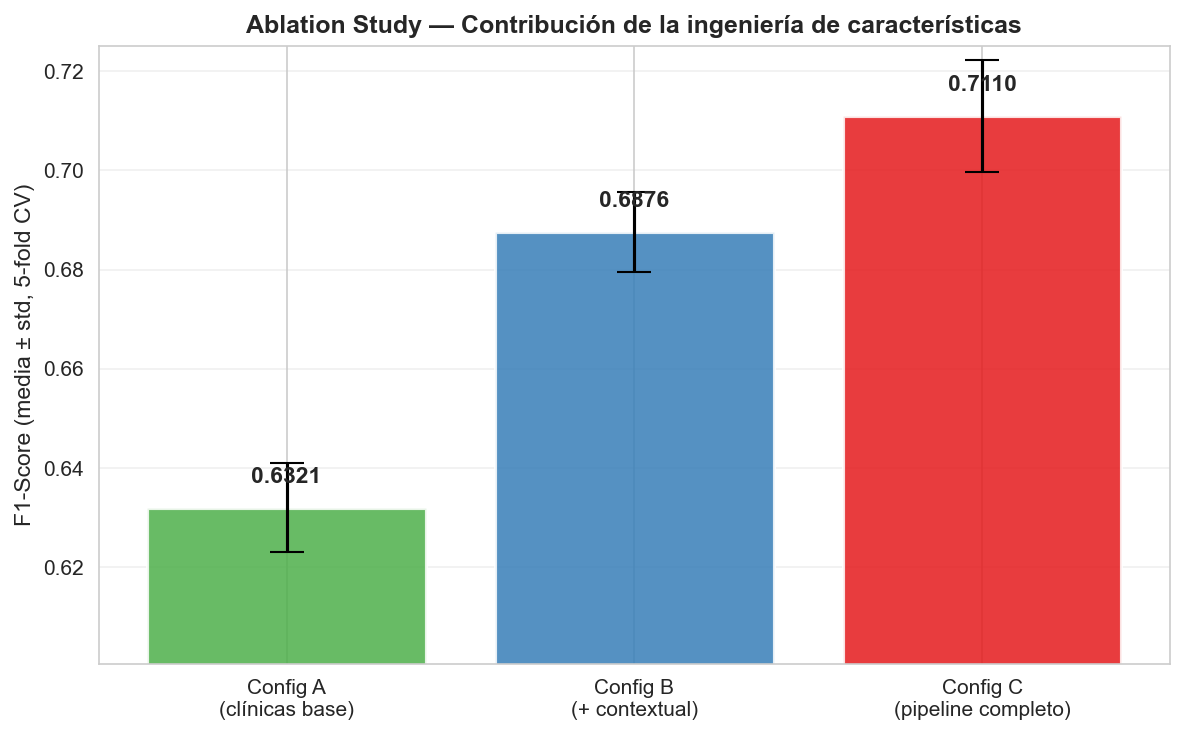

→ Figura exportada: figures/fig_ablation_study.png


In [16]:
# ── Figura del ablation study ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

cfgs = list(resultados_ablation.keys())
f1_means = [resultados_ablation[c]['f1'][0] for c in cfgs]
f1_stds = [resultados_ablation[c]['f1'][1] for c in cfgs]

colors = ['#4daf4a', '#377eb8', '#e41a1c']
bars = ax.bar(range(len(cfgs)), f1_means, yerr=f1_stds, capsize=8,
              color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)

# Anotar valores sobre cada barra
for bar, mean in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean:.4f}', ha='center', fontweight='bold', fontsize=11)

ax.set_xticks(range(len(cfgs)))
ax.set_xticklabels(['Config A\n(clínicas base)', 'Config B\n(+ contextual)',
                     'Config C\n(pipeline completo)'], fontsize=10)
ax.set_ylabel('F1-Score (media ± std, 5-fold CV)', fontsize=11)
ax.set_title('Ablation Study — Contribución de la ingeniería de características',
             fontsize=12, fontweight='bold')
ax.set_ylim(bottom=min(f1_means)*0.95, top=max(f1_means)*1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Figura exportada: figures/fig_ablation_study.png")


## 6. Optimización del *threshold* de clasificación

Por defecto, un clasificador binario asigna la clase positiva cuando la probabilidad predicha supera 0.50. Pero este umbral no tiene por qué ser óptimo: en un contexto clínico donde un falso negativo (paciente de alto riesgo no detectado) es más grave que un falso positivo, puede convenir un threshold inferior que aumente el *recall* a costa de algo de *precision*.

Aquí exploramos thresholds en el rango `[0.30, 0.70]` sobre el conjunto de validación *hold-out* (no usado durante el entrenamiento) y seleccionamos el que maximiza el F1-Score.


Threshold óptimo:        0.59
F1 en threshold óptimo:  0.7361
F1 en threshold default: 0.7271
Diferencia:              +0.0090


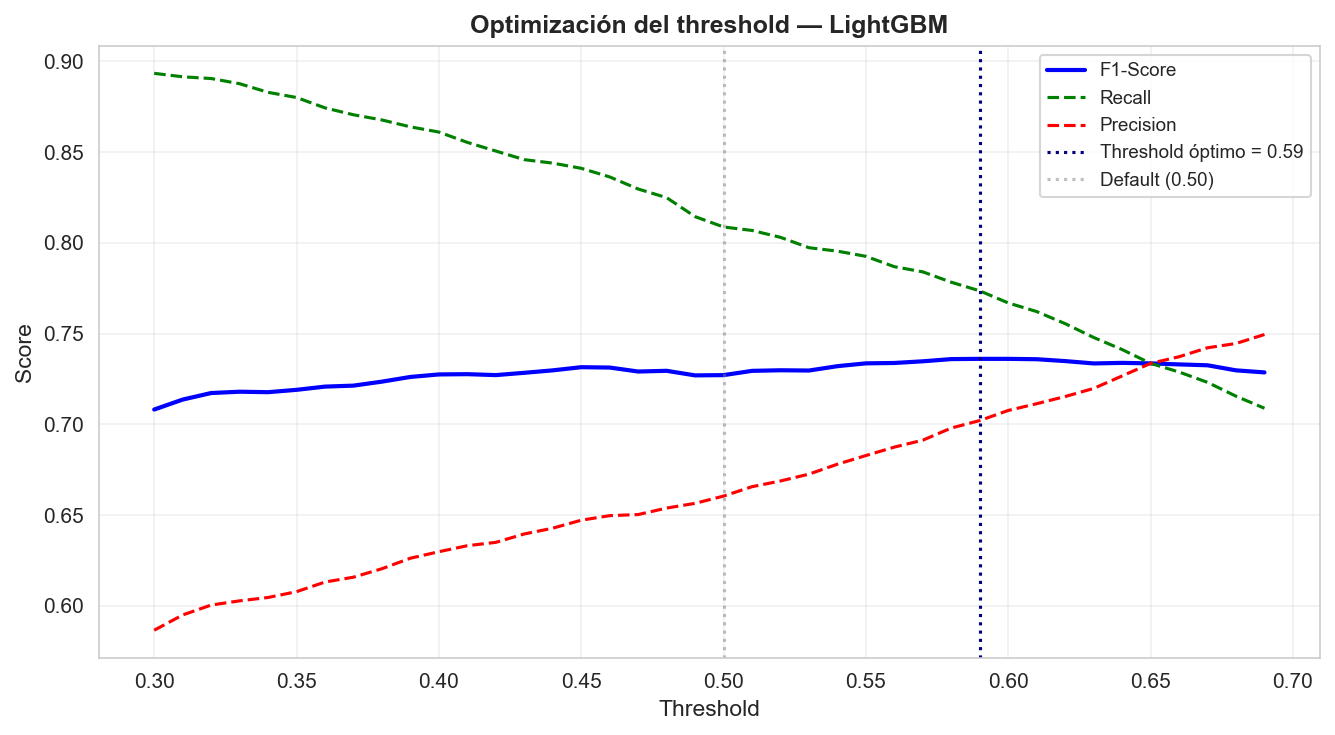

→ Figura exportada: figures/fig_threshold_optimization.png


In [17]:
# ── Entrenar LightGBM sobre el train set y evaluar en validación ──────────────
# Usamos la partición 80/20 (no el CV) para tener un hold-out limpio

# Paso 1: aplicar TE + imputer sobre el train set
te_final = TargetEncoder(columns=cols_alta_card_fe, smoothing=1.0)
te_final.fit(X_train_fe, y_train)
X_tr_t = te_final.transform(X_train_fe)
X_vl_t = te_final.transform(X_val_fe)

imp_final = SimpleImputer(strategy='median')
X_tr_t = pd.DataFrame(imp_final.fit_transform(X_tr_t), columns=X_tr_t.columns)
X_vl_t = pd.DataFrame(imp_final.transform(X_vl_t), columns=X_vl_t.columns)

# Paso 2: entrenar con hiperparámetros óptimos
modelo_lgbm.fit(X_tr_t, y_train)
y_val_proba = modelo_lgbm.predict_proba(X_vl_t)[:, 1]

# Paso 3: explorar thresholds
thresholds = np.arange(0.30, 0.70, 0.01)
f1_por_threshold = []
recall_por_threshold = []
precision_por_threshold = []

for thr in thresholds:
    y_pred_thr = (y_val_proba >= thr).astype(int)
    f1_por_threshold.append(f1_score(y_val, y_pred_thr))
    recall_por_threshold.append(recall_score(y_val, y_pred_thr))
    precision_por_threshold.append(precision_score(y_val, y_pred_thr))

mejor_thr = thresholds[np.argmax(f1_por_threshold)]
mejor_f1_thr = max(f1_por_threshold)
f1_default = f1_score(y_val, (y_val_proba >= 0.5).astype(int))

print(f"Threshold óptimo:        {mejor_thr:.2f}")
print(f"F1 en threshold óptimo:  {mejor_f1_thr:.4f}")
print(f"F1 en threshold default: {f1_default:.4f}")
print(f"Diferencia:              {mejor_f1_thr - f1_default:+.4f}")

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1_por_threshold, 'b-', linewidth=2, label='F1-Score')
ax.plot(thresholds, recall_por_threshold, 'g--', linewidth=1.5, label='Recall')
ax.plot(thresholds, precision_por_threshold, 'r--', linewidth=1.5, label='Precision')
ax.axvline(mejor_thr, color='navy', linestyle=':', linewidth=1.5,
           label=f'Threshold óptimo = {mejor_thr:.2f}')
ax.axvline(0.50, color='gray', linestyle=':', alpha=0.5, label='Default (0.50)')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Optimización del threshold — LightGBM', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"→ Figura exportada: figures/fig_threshold_optimization.png")


El threshold óptimo encontrado es **0,59**, ligeramente *superior* al default de 0,50, con una mejora de F1 de +0,009 (de 0,7271 a 0,7361). Esto significa que el modelo se beneficia de ser algo más conservador a la hora de clasificar como alto riesgo: necesita una probabilidad del 59% en vez del 50% para emitir una predicción positiva.

Este resultado puede parecer contraintuitivo en un contexto clínico donde, como se discutió en la sección de métricas, los falsos negativos son más graves que los falsos positivos. Sin embargo, tiene una explicación coherente: los modelos entrenados con `scale_pos_weight = 3,56` ya compensan el desbalanceo *durante el entrenamiento*, asignando más peso a la clase minoritaria. Esto hace que las probabilidades predichas estén desplazadas hacia arriba para los pacientes de riesgo. Al subir el threshold a 0,59, se contrarresta parcialmente este efecto y se recupera un equilibrio precision–recall más natural.

La mejora del threshold es modesta (+0,9% de F1), lo que indica que las probabilidades del modelo están razonablemente calibradas de serie y no dependen críticamente de un ajuste fino del umbral. Esto es una señal positiva de cara a la estabilidad del sistema en despliegue.

## 7. Exportación del modelo final y predicciones

Se exportan todos los artefactos necesarios para el equipo:

- **`cardis_modelo_final.joblib`**: contiene el modelo LightGBM entrenado, el Target Encoder, el imputer, el threshold óptimo, y los nombres de las features. Esto permite cargar el modelo en un solo paso para SHAP y para el despliegue.
- **`predicciones_lgbm_cv.csv`**: predicciones por fold de CV (y_true, y_pred, y_proba), necesarias para el análisis de equidad y calibración.
- **`predicciones_test.csv`**: predicciones sobre el dataset de evaluación sin etiquetar.
- **`hiperparametros_optimos.json`**: parámetros de los 4 modelos para reproducibilidad.


In [ ]:
# ── Entrenamiento final sobre TODO el training set ────────────────────────────
# (sin hold-out, para maximizar los datos disponibles en el modelo final)
print("Entrenando modelo final sobre el training set completo...")

te_export = TargetEncoder(columns=cols_alta_card_fe, smoothing=1.0)
te_export.fit(X_fe, y)
X_fe_encoded = te_export.transform(X_fe)

imp_export = SimpleImputer(strategy='median')
X_fe_imputed = pd.DataFrame(
    imp_export.fit_transform(X_fe_encoded),
    columns=X_fe_encoded.columns
)

modelo_final = lgb.LGBMClassifier(
    n_estimators=params_lgbm['n_estimators'],
    learning_rate=params_lgbm['learning_rate'],
    max_depth=params_lgbm['max_depth'],
    num_leaves=params_lgbm['num_leaves'],
    min_child_samples=params_lgbm['min_child_samples'],
    reg_alpha=params_lgbm['reg_alpha'],
    reg_lambda=params_lgbm['reg_lambda'],
    subsample=params_lgbm['subsample'],
    colsample_bytree=params_lgbm['colsample_bytree'],
    scale_pos_weight=spw_lgbm,
    random_state=SEED, verbose=-1, n_jobs=-1
)
modelo_final.fit(X_fe_imputed, y)

print(f"  ✓ Modelo: LightGBM")
print(f"  ✓ Threshold óptimo: {mejor_thr:.2f}")
print(f"  ✓ Features: {X_fe_imputed.shape[1]}")

# ── Exportar artefactos del modelo ────────────────────────────────────────────
artefactos = {
    'modelo': modelo_final,
    'target_encoder': te_export,
    'imputer': imp_export,
    'threshold': mejor_thr,
    'feature_names': X_fe_imputed.columns.tolist(),
    'params': params_lgbm,
    'seed': SEED
}
joblib.dump(artefactos, 'models/cardis_modelo_final.joblib')
print(f"\n→ Modelo exportado: models/cardis_modelo_final.joblib")

# ── Exportar predicciones por fold ───────────────────────────
res_lgbm['predicciones'].to_csv('outputs/predicciones_lgbm_cv.csv', index=False)
print(f"→ Predicciones CV: outputs/predicciones_lgbm_cv.csv")

# ── Exportar hiperparámetros de los 4 modelos ─────────────────────────────────
all_params = {
    'logistic_regression': params_lr,
    'random_forest': params_rf,
    'lightgbm': params_lgbm,
    'xgboost': params_xgb,
    'threshold_optimo': float(mejor_thr)
}
with open('outputs/hiperparametros_optimos.json', 'w') as f:
    json.dump(all_params, f, indent=2, default=str)
print(f"→ Hiperparámetros: outputs/hiperparametros_optimos.json")

# ── Predicciones sobre el test set (sin etiquetar) ────────────────────────────
X_test_encoded = te_export.transform(df_test_fe)
X_test_imputed = pd.DataFrame(
    imp_export.transform(X_test_encoded),
    columns=X_test_encoded.columns
)
y_test_proba = modelo_final.predict_proba(X_test_imputed)[:, 1]
y_test_pred = (y_test_proba >= mejor_thr).astype(int)

df_test_pred = pd.DataFrame({
    'y_pred': y_test_pred,
    'y_proba': y_test_proba
})
df_test_pred.to_csv('outputs/predicciones_test.csv', index=False)
print(f"→ Predicciones test: outputs/predicciones_test.csv")
print(f"  Distribución: {y_test_pred.sum()} alto riesgo ({y_test_pred.mean():.2%})")


Entrenando modelo final sobre el training set completo...
  ✓ Modelo: LightGBM
  ✓ Threshold óptimo: 0.59
  ✓ Features: 38

→ Modelo exportado: models/cardis_modelo_final.joblib
→ Predicciones CV: outputs/predicciones_lgbm_cv.csv
→ Hiperparámetros: outputs/hiperparametros_optimos.json
→ Predicciones test: outputs/predicciones_test.csv
  Distribución: 3754 alto riesgo (23.46%)


La distribución de predicciones en el test set (23,5% alto riesgo) es coherente con la prevalencia real del dataset de entrenamiento (21,9%). El ligero exceso de predicciones positivas es esperable dado que el modelo usa `scale_pos_weight = 3,56`, que sesga las probabilidades hacia la clase minoritaria. El threshold de 0,59 corrige parcialmente este efecto, pero la proporción final sigue siendo razonable y no presenta signos de sesgo extremo.

El modelo final, el Target Encoder, el imputer y el threshold quedan encapsulados en un único archivo `.joblib` para que puedan cargarse directamente en el despliegue y en el análisis SHAP sin necesidad de re-ejecutar el pipeline de entrenamiento.


## 8. Resumen de resultados

Los archivos generados por este notebook se resumen a continuación:

| Archivo | Contenido |
| :--- | :--- |
| `outputs/tabla_comparativa_modelos.csv` | Métricas de los 4 modelos (5-fold CV) |
| `outputs/tests_wilcoxon.csv` | Tests estadísticos entre pares |
| `figures/fig_ablation_study.png` | Contribución incremental del FE |
| `figures/fig_threshold_optimization.png` | Curva F1 vs threshold |
| `outputs/predicciones_lgbm_cv.csv` | y_true, y_pred, y_proba por fold |
| `models/cardis_modelo_final.joblib` | Modelo + TE + imputer + threshold |
| `outputs/hiperparametros_optimos.json` | Params de los 4 modelos + threshold |
| `outputs/predicciones_test.csv` | Predicciones en test set |
| `outputs/dependencias.json` | Versiones de librerías |

## 9. Conclusiones del experimento

### ¿Qué modelo hemos elegido y por qué?

Tras comparar cuatro modelos (desde una Regresión Logística clásica hasta algoritmos de *boosting* como LightGBM y XGBoost) el resultado más llamativo es lo **cerca que están todos entre sí**. La diferencia entre el mejor (LightGBM, F1 = 0,7197) y el *baseline* lineal (Regresión Logística, F1 = 0,7158) es de apenas 0,004 puntos: prácticamente indistinguible y, de hecho, no significativa estadísticamente. Esto nos dice algo importante: **el pipeline de datos que construimos en el Hito 2 es sólido**. Cuando modelos de familias muy diferentes convergen en rendimiento, la señal está en los datos, no en el algoritmo.

Seleccionamos **LightGBM** como modelo final, no porque sea drásticamente superior en F1, sino por el conjunto de sus propiedades: tiene la mejor calibración de probabilidades (Brier = 0,0959), es compatible con SHAP para generar las explicaciones que CARDIS necesita mostrar al médico, y su velocidad de inferencia (∼1 segundo) lo hace viable para despliegue en tiempo real.

### ¿Qué hemos aprendido?

Los resultados permiten responder a las dos preguntas de investigación planteadas:

**RQ1 - ¿Qué modelo ofrece el mejor equilibrio rendimiento–explicabilidad?** LightGBM, pero con un matiz relevante: la Regresión Logística, un modelo inherentemente interpretable, rinde casi igual. Esto refuerza el caso para la explicabilidad en CARDIS: no necesitamos sacrificar transparencia para obtener buen rendimiento.

**RQ2 - ¿Cuánto aporta la ingeniería de características?** Mucho. El *ablation study* muestra que pasar de las variables clínicas originales (F1 = 0,6321) al pipeline completo (F1 = 0,7110) supone una mejora de casi 8 puntos. Las variables que más aportan son las contextuales (actividad física, indicadores de *missing*, temporales), seguidas de las *keywords* clínicas extraídas de las notas médicas. El esfuerzo de preprocesamiento del Hito 2 ha merecido la pena.

### En resumen

El sistema CARDIS, con los datos disponibles, es capaz de **identificar correctamente a casi 8 de cada 10 pacientes de alto riesgo cardiovascular** (recall ≈ 0,78) con una tasa de falsas alarmas razonable (precision ≈ 0,67). No es un sistema perfecto (ninguno lo es con datos sintéticos y sin variables como el sexo) pero es un punto de partida sólido para un sistema de apoyo a la decisión clínica que, recordemos, no toma decisiones por sí solo: presenta una estimación de riesgo al médico, que es quien decide.

## Declaración de uso de inteligencia artificial

Los autores del presente trabajo declaran que todas las decisiones de diseño experimental, la selección de modelos y métricas, la interpretación de los resultados y las conclusiones han sido tomadas de forma íntegra por los miembros del equipo, apoyándose en los conocimientos adquiridos en la asignatura y en la literatura de referencia.

La inteligencia artificial (Claude, Anthropic) ha sido empleada como herramienta de apoyo en las siguientes tareas instrumentales:

- **Asistencia en código:** generación de estructuras base de notebooks, funciones de evaluación y visualización, que posteriormente fueron revisadas, adaptadas y validadas por los autores.
- **Redacción y estilo:** revisión ortográfica y estilística del texto, así como sugerencias de estructura para las celdas de markdown explicativas.
- **Apoyo en la resolución de problemas técnicos:** en particular, diagnóstico de problemas de convergencia en la optimización de la Regresión Logística (selección del solver `liblinear` frente a `saga`) y ajuste de espacios de hiperparámetros.
- **Contraste de interpretaciones:** en algunos resultados cuya lectura no era inmediata (como la aparente contradicción entre AUC-ROC y F1 en la Regresión Logística, o el perfil clínico de los falsos negativos), la IA se utilizó como interlocutor para contrastar hipótesis, cuya validez fue siempre verificada por los autores.

En ningún caso la inteligencia artificial ha sustituido el criterio técnico o académico del equipo. Los autores asumen plena responsabilidad sobre el contenido, los análisis y las conclusiones de este trabajo.